<a href="https://www.kaggle.com/code/tarzon/custom-word-cloud?scriptVersionId=219186651" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  Custom Word Cloud ☁️

Get ready for an exciting adventure into the world of creative design! 

🎨✨ In this notebook, we’ll bring your imagination to life by crafting vibrant, colorful word clouds in unique shapes. With just a few lines of code, you’ll unleash your creativity and design personalized word clouds that are as stunning as they are meaningful. 

Let’s dive in and start making magic! 🚀🌈

I came across a detailed article that walks you through the code—check it out at the link below:
[Create a Customized Word Cloud](https://medium.com/@parulrajput27/create-a-customized-word-cloud-4d119df446f)


***Import libraries***

Before we dive into the magic, let’s bring in some powerful tools! 🚀✨ We’ll import all the essential libraries to help us craft our vibrant, custom word clouds with ease. Let’s gear up! 📚🎨

In [30]:
import numpy as np  # used for multidimensional arrays and matrixes.
import pandas as pd  #used for data analysis
import matplotlib.pyplot as plt  # used for visualisation

from PIL import Image #for collecting different images
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator   # generate word cloud

***Load dataset***


Now, I’m going to work with two amazing datasets to create a custom word cloud! The first dataset, ["source-based-news-classification"](https://www.kaggle.com/ruchi798/source-based-news-classification), is packed with fake news classification data, which we’ll use as our source for the word cloud. And to make it even more exciting, the second dataset, ["word cloud mask image"](https://www.kaggle.com/tarzon/input-img), is a collection of awesome mask images that will give our word cloud a unique shape. Let’s get started on this creative journey! 🎨✨


In [31]:
df=pd.read_csv("../input/source-based-news-classification/news_articles.csv")

In [32]:
df.head()


,author,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
0,Barracuda Brigade,2016-10-26T21:41:00.000+03:00,muslims busted they stole millions in govt ben...,print they should pay all the back all the mon...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,muslims busted stole millions govt benefits,print pay back money plus interest entire fami...,1.0
1,reasoning with facts,2016-10-29T08:47:11.259+03:00,re why did attorney general loretta lynch plea...,why did attorney general loretta lynch plead t...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,attorney general loretta lynch plead fifth,attorney general loretta lynch plead fifth bar...,1.0
2,Barracuda Brigade,2016-10-31T01:41:49.479+02:00,breaking weiner cooperating with fbi on hillar...,red state \nfox news sunday reported this mor...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,breaking weiner cooperating fbi hillary email ...,red state fox news sunday reported morning ant...,1.0
3,Fed Up,2016-11-01T05:22:00.000+02:00,pin drop speech by father of daughter kidnappe...,email kayla mueller was a prisoner and torture...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,pin drop speech father daughter kidnapped kill...,email kayla mueller prisoner tortured isis cha...,1.0
4,Fed Up,2016-11-01T21:56:00.000+02:00,fantastic trumps point plan to reform healthc...,email healthcare reform to make america great ...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,fantastic trumps point plan reform healthcare ...,email healthcare reform make america great sin...,1.0


In [33]:
df.isnull().sum()

author                      0
published                   0
title                       0
text                       46
language                    1
site_url                    1
main_img_url                1
type                        1
label                       1
title_without_stopwords     2
text_without_stopwords     50
hasImage                    1
dtype: int64

In [34]:
df=df.dropna()

In [35]:
text=(' '.join(df['text_without_stopwords']))

In this dataset we already have preprocessed data(no missing value, without stop words, ). We can directly use the column "text without stopwords".

(-0.5, 399.5, 199.5, -0.5)

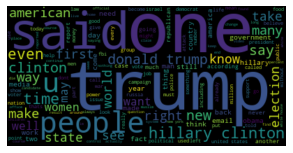

In [36]:
# Create and Generate a Word Cloud Image
wordcloud = WordCloud().generate(text)

#Display the generated image
plt.figure(figsize=[5,5])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

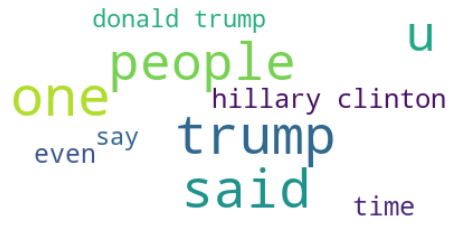

In [37]:
#change font_size, max_word and background_color
wordcloud = WordCloud(max_font_size=50, max_words=10, background_color="white").generate(text)

#Display the image
plt.figure(figsize=[8,8])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

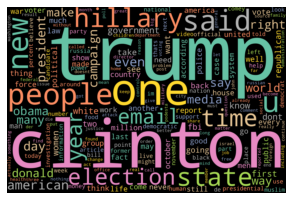

In [38]:
# Create stopword list:
stopwords = set(STOPWORDS)

# Generate a word cloud image
wordcloud = WordCloud(width = 3000, height = 2000, random_state=1, background_color='black', colormap='Set2', collocations=False, stopwords = STOPWORDS).generate(text)

# Display the generated image
plt.figure(figsize=[5,5])
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

**Let’s bring words to life with stunning shapes! 🌟✨**

In [39]:
mask=np.array(Image.open("../input/input-img/cloud1.png"))

In [40]:
def transform_format(val):
    if val == 0:
        return 255
    else:
        return val

In [41]:
# Transform mask into a new one that will work with the function:
transformed_mask = np.ndarray((mask.shape[0],mask.shape[1]), np.int32)

for i in range(len(mask)):
    transformed_mask[i] = list(map(transform_format, mask[i]))

<Figure size 432x288 with 0 Axes>

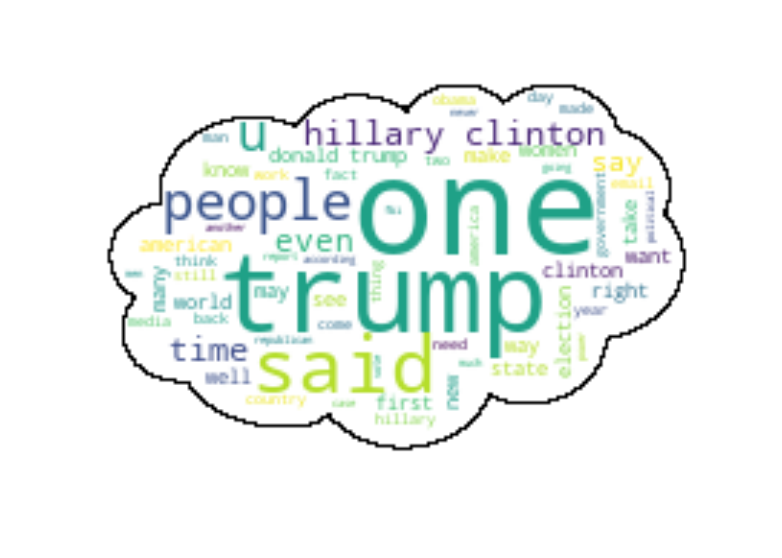

In [42]:
# Create a word cloud image
wc = WordCloud(width = 3000, height = 2000,background_color="white", max_words=100, mask=transformed_mask,
               stopwords=stopwords, contour_width=1)

# Generate a wordcloud
wc.generate(text)

# store to file
plt.savefig("cloud.png", format="png")

# show
plt.figure( figsize=[20,10])
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

Next up, we’re stepping up the game by using pre-transformed mask images that will add an exciting touch to our word cloud design! 🎭

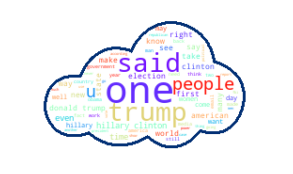

In [43]:
# Generate a word cloud image
stopwords = set(STOPWORDS)
mask = np.array(Image.open("../input/input-img/download1.png"))

wordcloud = WordCloud(stopwords=stopwords,background_color='white', max_words=1000, mask=mask,contour_color='#023075',contour_width=3,colormap='rainbow').generate(' '.join(df['text_without_stopwords']))

# create image as cloud
plt.figure(figsize=[5,10])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

# store to file
plt.savefig("cloud.png", format="png")
plt.show()

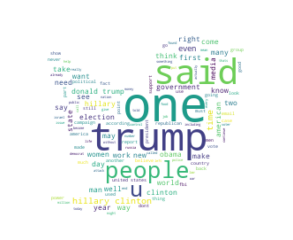

In [44]:
# Generate a word cloud image
stopwords = set(STOPWORDS)
mask = np.array(Image.open("../input/input-img/Twitter.png"))


wordcloud = WordCloud(stopwords=stopwords, background_color="white", max_words=1000, mask=mask).generate(' '.join(df['text_without_stopwords']))

# create twitter image
plt.figure(figsize=[5,10])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

# store to file
plt.savefig("twitter.png", format="png")
plt.show()

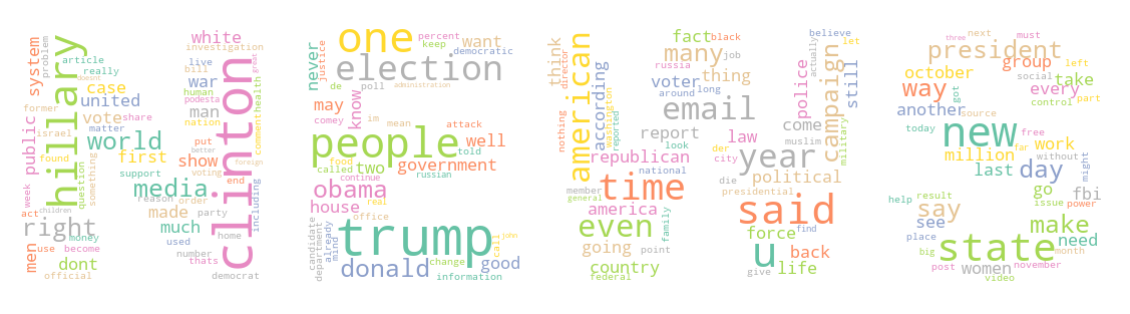

In [45]:
# Generate a word cloud image
stopwords = set(STOPWORDS)
mask = np.array(Image.open("../input/input-img/News_mask.PNG"))

wordcloud = WordCloud(width = 3000, height = 2000, random_state=1, background_color='white', colormap='Set2', collocations=False, stopwords = STOPWORDS,mask=mask).generate(' '.join(df['text_without_stopwords']))

# create coloring from image
image_colors = ImageColorGenerator(mask)
plt.figure(figsize=[20,20])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

# store to file
plt.savefig("news.png", format="png") 
plt.show()

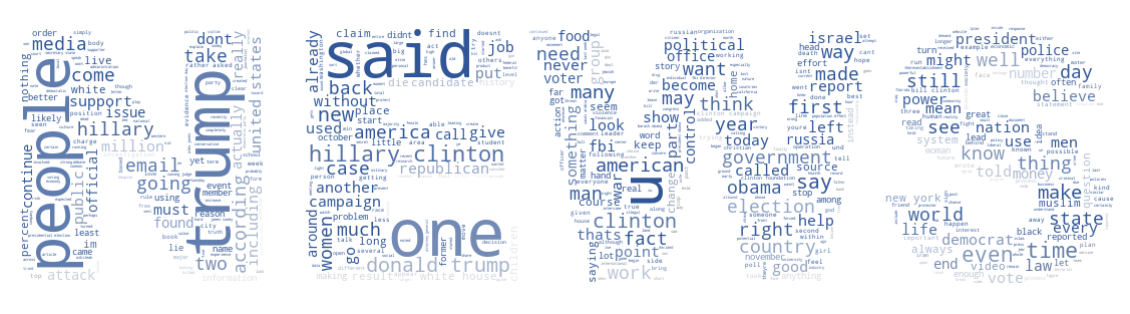

In [46]:
# Generate a word cloud image
stopwords = set(STOPWORDS)
mask = np.array(Image.open("../input/input-img/News_mask.PNG"))

wordcloud = WordCloud(stopwords=stopwords, background_color="white", mode="RGBA", max_words=1000, mask=mask).generate(' '.join(df['text_without_stopwords']))

# create coloring from image
image_colors = ImageColorGenerator(mask)
plt.figure(figsize=[20,20])
plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear")
plt.axis("off")

# store to file
plt.savefig("news1.png", format="png") 
plt.show()

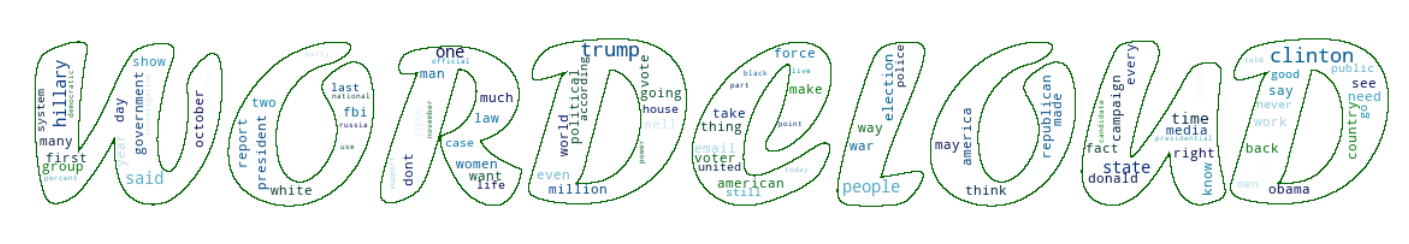

In [47]:
# Generate a word cloud image
stopwords = set(STOPWORDS)
mask = np.array(Image.open("../input/input-img/headerimg.PNG"))

wordcloud = WordCloud(width = 3000, height = 2000, max_words=100, random_state=1, background_color='white', contour_color='darkgreen',contour_width=1, colormap='ocean_r', collocations=False, stopwords = STOPWORDS,mask=mask).generate(' '.join(df['text_without_stopwords']))

# create coloring from image
image_colors = ImageColorGenerator(mask)
plt.figure(figsize=[25,25])
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

# store to file
plt.savefig("wordcloud.png", format="png") 
plt.show()

I've shared the full details of the code in my article,

["Creating Customized Word Cloud"](https://medium.com/@parulrajput27/create-a-customized-word-cloud-4d119df446f) 🎉


Thank you so much for reading! 😊 I hope you enjoyed this creative journey. If you liked it, don’t forget to hit that UPVOTE! 🙌✨

     |████████████████████████████████| 8.9 MB 9.7 MB/s eta 0:00:01
     |████████████████████████████████| 82 kB 115 kB/s  eta 0:00:01
     |████████████████████████████████| 311 kB 71.4 MB/s eta 0:00:01
     |████████████████████████████████| 7.0 MB 23.5 MB/s eta 0:00:01
     |████████████████████████████████| 241 kB 45.7 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 57.2 MB/s eta 0:00:01
     |████████████████████████████████| 84 kB 2.2 MB/s  eta 0:00:01
  Created wheel for validators: filename=validators-0.20.0-py3-none-any.whl size=19567 sha256=b5ec1557902a3fa18abb52a03d20e58025ad1432383d0c25ffe1152720e2c438
  Stored in directory: /root/.cache/pip/wheels/5f/55/ab/36a76989f7f88d9ca7b1f68da6d94252bb6a8d6ad4f18e04e9
Successfully built validators
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.7.4.3
    Uninstalling typing-extensions-3.7.4.3:
      Successfully uninstalled typing-extensions-3.7.4.3
  Attempting uninstall

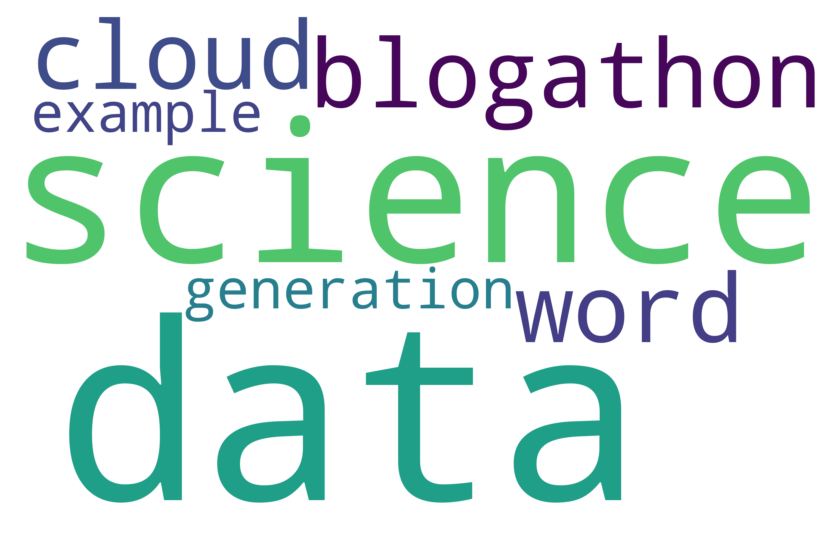

In [1]:
# Install the required libraries
!pip install wordcloud numpy pandas matplotlib pillow opencv-python scikit-image spacy streamlit transformers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from skimage import io, img_as_ubyte, img_as_bool
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import cv2

# Load and preprocess text data
# Example using spaCy for text cleaning and lemmatization
nlp = spacy.load("en_core_web_sm")
def preprocess_text(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return " ".join(tokens)

# Sample text (use your dataset here)
text_data = """Data Science Blogathon Word Cloud generation example"""

# Preprocess the text
cleaned_text = preprocess_text(text_data)

# Load a mask image and preprocess it
mask_image_path = "cloud.png"  # Replace with your mask image path
mask = cv2.imread(mask_image_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.threshold(mask, 128, 255, cv2.THRESH_BINARY)[1]  # Ensure binary mask

# Generate word cloud
wordcloud = WordCloud(
    width=3000,
    height=2000,
    background_color="white",
    colormap="viridis",
    max_words=500,
    mask=mask,
    contour_width=3,
    contour_color="steelblue",
    stopwords=STOPWORDS
).generate(cleaned_text)

# Display the word cloud
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Save the word cloud to a file
wordcloud.to_file("modern_wordcloud.png")
